In [ ]:
import os, random, numpy as np, pandas as pd, torch
from tqdm import tqdm
import nltk
from nltk.tokenize import sent_tokenize
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW  # stable import across transformers versions

# File Paths
LABELED_CSV         = "labeled_sentences_1.csv"
SPEECHES_CSV        = "bsp_speech_dataset.csv"
SAVE_MODEL_DIR      = "finetuned_econobert_bsp_sent"
OUT_DIR             = "out_econobert"

# Column Names
TEXT_COL_LABELED    = "sentence"
LABEL_COL_LABELED   = "label"                 # must be one of {negative, neutral, positive}
TEXT_COL_SPEECHES   = "Text"
ID_COL_SPEECHES     = "index"
DATE_COL_SPEECHES   = "Date"

# Training Hyperparams
BASE_MODEL          = "samchain/EconoBert"         # EconoBERT checkpoint
MAX_LENGTH_TRAIN    = 256
BATCH_SIZE_TRAIN    = 16
EPOCHS              = 5
LR                  = 2e-5
WEIGHT_DECAY        = 0.01
WARMUP_STEPS        = 0
SEED                = 42

# Scoring Hyperparams
MAX_LENGTH_SCORE    = 512
BATCH_SIZE_SCORE    = 32

# Dixed Sentiment Label Order
LABEL_ORDER = ["negative", "neutral", "positive"]

# Setup
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

try: nltk.data.find("tokenizers/punkt")
except LookupError: nltk.download("punkt")
try: nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    try: nltk.download("punkt_tab")
    except: pass

device = "cuda" if torch.cuda.is_available() else "cpu"
device


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


'cuda'

In [ ]:
# Load labeled sentences
df_lab = pd.read_csv(LABELED_CSV).dropna(subset=[TEXT_COL_LABELED, LABEL_COL_LABELED]).copy()

# Enforce exact labels
df_lab[LABEL_COL_LABELED] = df_lab[LABEL_COL_LABELED].str.lower().str.strip()
unknown = set(df_lab[LABEL_COL_LABELED].unique()) - set(LABEL_ORDER)
if unknown:
    raise ValueError(f"Found unknown labels {unknown}. Labels must be exactly {LABEL_ORDER}.")

label2id = {lab:i for i, lab in enumerate(LABEL_ORDER)}
id2label = {v:k for k,v in label2id.items()}
df_lab["label_id"] = df_lab[LABEL_COL_LABELED].map(label2id)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df_lab, test_size=0.2, random_state=SEED, stratify=df_lab["label_id"]
)

len(train_df), len(val_df), train_df[LABEL_COL_LABELED].value_counts()


(3640,
 910,
 label
 positive    1734
 neutral     1646
 negative     260
 Name: count, dtype: int64)

In [ ]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

class SentDataset(Dataset):
    def __init__(self, df, text_col, label_col_id, tokenizer, max_length):
        self.texts = df[text_col].tolist()
        self.labels = df[label_col_id].astype(int).tolist()
        self.tok = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True, max_length=self.max_length, padding=False,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def collate_fn_factory(tokenizer):
    def collate_fn(batch):
        keys = batch[0].keys()
        to_pad = {k: [b[k] for b in batch] for k in keys}
        return tokenizer.pad(to_pad, padding=True, return_tensors="pt")
    return collate_fn

train_ds = SentDataset(train_df, TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)
val_ds   = SentDataset(val_df,   TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  collate_fn=collate_fn_factory(tok))
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE_TRAIN, shuffle=False, collate_fn=collate_fn_factory(tok))

len(train_dl), len(val_dl)


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

(228, 57)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL_ORDER),
    id2label=id2label,
    label2id=label2id,
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
num_training_steps = EPOCHS * len(train_dl)
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=num_training_steps
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: samchain/EconoBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def metrics_from_preds(preds, labels, num_labels):
    preds = np.asarray(preds); labels = np.asarray(labels)
    acc = (preds == labels).mean() if len(labels) else 0.0
    f1s = []
    for c in range(num_labels):
        tp = np.sum((preds==c) & (labels==c))
        fp = np.sum((preds==c) & (labels!=c))
        fn = np.sum((preds!=c) & (labels==c))
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        f1s.append(f1)
    return {"accuracy": float(acc), "f1_macro": float(np.mean(f1s))}

best_f1 = -1.0

for ep in range(1, EPOCHS+1):
    # Train
    model.train()
    tr_loss = 0.0
    for batch in tqdm(train_dl, desc=f"Epoch {ep}/{EPOCHS} - train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = loss_fn(out.logits, batch["labels"])
        loss.backward()
        tr_loss += loss.item()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    tr_loss /= max(1, len(train_dl))

    # Validate
    model.eval()
    val_loss = 0.0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {ep}/{EPOCHS} - val"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = loss_fn(out.logits, batch["labels"])
            val_loss += loss.item()
            preds = out.logits.argmax(dim=-1).cpu().numpy().tolist()
            lbls  = batch["labels"].cpu().numpy().tolist()
            preds_all.extend(preds); labels_all.extend(lbls)
    val_loss /= max(1, len(val_dl))
    m = metrics_from_preds(preds_all, labels_all, len(LABEL_ORDER))
    print(f"Epoch {ep:02d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | "
          f"acc {m['accuracy']:.3f} | f1_macro {m['f1_macro']:.3f}")

    # Save best
    if m["f1_macro"] > best_f1:
        best_f1 = m["f1_macro"]
        model.save_pretrained(SAVE_MODEL_DIR)
        tok.save_pretrained(SAVE_MODEL_DIR)
        with open(os.path.join(SAVE_MODEL_DIR, "labels.txt"), "w") as f:
            for lab in LABEL_ORDER: f.write(lab + "\n")
        print(f"  ↳ Saved best to {SAVE_MODEL_DIR} (f1_macro={best_f1:.3f})")


Epoch 1/5 - val: 100%|██████████| 57/57 [00:03<00:00, 17.22it/s]


Epoch 01 | train_loss 0.7416 | val_loss 0.5573 | acc 0.749 | f1_macro 0.731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↳ Saved best to finetuned_econobert_bsp_sent (f1_macro=0.731)


Epoch 2/5 - val: 100%|██████████| 57/57 [00:03<00:00, 15.60it/s]


...

  ↳ Saved best to finetuned_econobert_bsp_sent (f1_macro=0.763)


Epoch 4/5 - val: 100%|██████████| 57/57 [00:03<00:00, 15.10it/s]


Epoch 04 | train_loss 0.1484 | val_loss 0.7618 | acc 0.744 | f1_macro 0.726


Epoch 5/5 - val: 100%|██████████| 57/57 [00:03<00:00, 15.24it/s]

Epoch 05 | train_loss 0.0894 | val_loss 0.7936 | acc 0.753 | f1_macro 0.729


In [ ]:
clf_tok = AutoTokenizer.from_pretrained(SAVE_MODEL_DIR)
clf_mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_MODEL_DIR).to(device).eval()

def softmax_np(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=-1, keepdims=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating best saved EconoBERT model: 100%|██████████| 57/57 [00:03<00:00, 15.34it/s]


Label order used:
['negative', 'neutral', 'positive']

Model id2label:
{0: 'negative', 1: 'neutral', 2: 'positive'}

Model label2id:
{'negative': 0, 'neutral': 1, 'positive': 2}

Validation Loss: 0.6247

Overall Metrics:
accuracy: 0.7725
precision_macro: 0.7519
recall_macro: 0.7755
f1_macro: 0.7628
precision_weighted: 0.7731
recall_weighted: 0.7725
f1_weighted: 0.7726
mcc: 0.5988

Per-Class Metrics:
      label  precision    recall  f1_score  support
0  negative   0.698630  0.784615  0.739130       65
1   neutral   0.766169  0.747573  0.756757      412
2  positive   0.790805  0.794457  0.792627      433

Classification Report:

              precision    recall  f1-score   support

    negative     0.6986    0.7846    0.7391        65
     neutral     0.7662    0.7476    0.7568       412
    positive     0.7908    0.7945    0.7926       433

    accuracy                         0.7725       910
   macro avg     0.7519    0.7755    0.7628       910
weighted avg     0.7731    0.7725    0

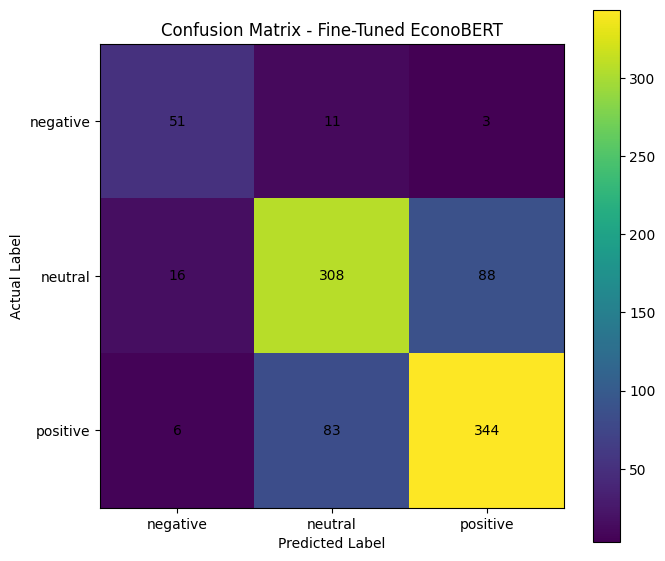

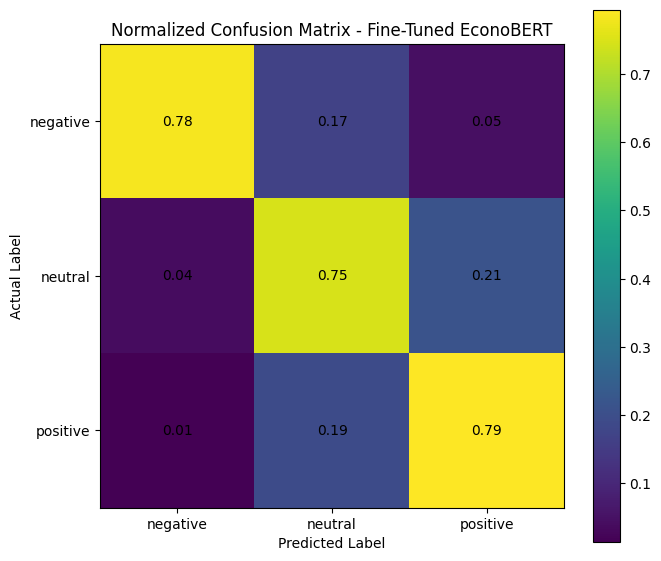


Saved files:
out_econobert/econobert_overall_metrics.csv
out_econobert/econobert_per_class_metrics.csv
out_econobert/econobert_classification_report.csv
out_econobert/econobert_confusion_matrix.csv
out_econobert/econobert_confusion_matrix_normalized.csv
out_econobert/econobert_confusion_matrix.png
out_econobert/econobert_confusion_matrix_normalized.png
out_econobert/econobert_val_predictions.csv
out_econobert/econobert_misclassified_validation_examples.csv

Top 20 highest-confidence misclassified examples:


,sentence,label,true_label,pred_label,p_neg,p_neu,p_pos,confidence
662,"To all our guests, we thank you once again for...",neutral,neutral,positive,0.001972,0.010435,0.987593,0.987593
519,"In the balance of payments, a meaningful but o...",neutral,neutral,positive,0.002947,0.011263,0.985790,0.985790
537,"In many of our neighbors, one key reason why i...",neutral,neutral,negative,0.983621,0.010087,0.006292,0.983621
316,"The expected expenditures for relief, rehab an...",neutral,neutral,positive,0.003082,0.014773,0.982145,0.982145
430,This should exert a positive influence on the ...,neutral,neutral,positive,0.002326,0.016228,0.981445,0.981445
52,This has allowed us to sustain our annual sear...,neutral,neutral,positive,0.002593,0.019143,0.978265,0.978265
71,"Of course, holding a public official accountab...",positive,positive,neutral,0.009815,0.976880,0.013305,0.976880
384,You can never be wrong when you pursue your ma...,positive,positive,neutral,0.003540,0.976767,0.019692,0.976767
501,"Warren Buffet once said, ""You only find out wh...",neutral,neutral,positive,0.002155,0.021939,0.975906,0.975906
830,"For this, we will look to the work of the stan...",positive,positive,neutral,0.003231,0.975730,0.021040,0.975730


In [ ]:
# VALIDATION METRICS + CONFUSION MATRICES FOR BEST SAVED ECONOBERT MODEL

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)
import matplotlib.pyplot as plt

def compute_metrics_full(preds, labels, label_names):
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    acc = accuracy_score(labels, preds)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    prec_class, rec_class, f1_class, support_class = precision_recall_fscore_support(
        labels,
        preds,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0
    )

    mcc = matthews_corrcoef(labels, preds)

    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "mcc": float(mcc)
    }

    per_class_df = pd.DataFrame({
        "label": label_names,
        "precision": prec_class,
        "recall": rec_class,
        "f1_score": f1_class,
        "support": support_class
    })

    return metrics, per_class_df


def evaluate_model(model, data_loader, device, loss_fn, label_order):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating best saved EconoBERT model"):
            batch = {k: v.to(device) for k, v in batch.items()}

            out = model(**batch)
            loss = loss_fn(out.logits, batch["labels"])
            total_loss += loss.item()

            logits = out.logits.detach().cpu().numpy()
            probs = softmax_np(logits)
            preds = probs.argmax(axis=1)
            labels = batch["labels"].detach().cpu().numpy()

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = total_loss / max(1, len(data_loader))

    metrics, per_class_df = compute_metrics_full(
        preds=all_preds,
        labels=all_labels,
        label_names=label_order
    )

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(label_order)))
    )

    cm_norm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(label_order))),
        normalize="true"
    )

    return {
        "val_loss": avg_loss,
        "metrics": metrics,
        "per_class_df": per_class_df,
        "confusion_matrix": cm,
        "confusion_matrix_normalized": cm_norm,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "probs": np.array(all_probs)
    }


# Evaluate validation set only
results = evaluate_model(
    model=clf_mdl,
    data_loader=val_dl,
    device=device,
    loss_fn=loss_fn,
    label_order=LABEL_ORDER
)

# Print label mapping to verify class order
print("Label order used:")
print(LABEL_ORDER)

print("\nModel id2label:")
print(clf_mdl.config.id2label)

print("\nModel label2id:")
print(clf_mdl.config.label2id)

# Print overall metrics
print("\nValidation Loss:", round(results["val_loss"], 4))

print("\nOverall Metrics:")
for k, v in results["metrics"].items():
    print(f"{k}: {v:.4f}")

# Print per-class metrics
print("\nPer-Class Metrics:")
print(results["per_class_df"])

# Print classification report
print("\nClassification Report:\n")
print(
    classification_report(
        results["labels"],
        results["preds"],
        labels=list(range(len(LABEL_ORDER))),
        target_names=LABEL_ORDER,
        digits=4,
        zero_division=0
    )
)

# Raw confusion matrix as dataframe
cm_df = pd.DataFrame(
    results["confusion_matrix"],
    index=[f"Actual_{label}" for label in LABEL_ORDER],
    columns=[f"Predicted_{label}" for label in LABEL_ORDER]
)

print("\nConfusion Matrix")
print(cm_df)

# Normalized confusion matrix as dataframe
cm_norm_df = pd.DataFrame(
    results["confusion_matrix_normalized"],
    index=[f"Actual_{label}" for label in LABEL_ORDER],
    columns=[f"Predicted_{label}" for label in LABEL_ORDER]
)

print("\nNormalized Confusion Matrix")
print(cm_norm_df.round(4))

# Plot raw confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(results["confusion_matrix"])
plt.title("Confusion Matrix - Fine-Tuned EconoBERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)
plt.yticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)

for i in range(len(LABEL_ORDER)):
    for j in range(len(LABEL_ORDER)):
        plt.text(
            j,
            i,
            str(results["confusion_matrix"][i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

cm_img_out = os.path.join(OUT_DIR, "econobert_confusion_matrix.png")
plt.savefig(cm_img_out, dpi=300, bbox_inches="tight")
plt.show()

# Plot normalized confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(results["confusion_matrix_normalized"])
plt.title("Normalized Confusion Matrix - Fine-Tuned EconoBERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)
plt.yticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)

for i in range(len(LABEL_ORDER)):
    for j in range(len(LABEL_ORDER)):
        plt.text(
            j,
            i,
            f"{results['confusion_matrix_normalized'][i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

cm_norm_img_out = os.path.join(OUT_DIR, "econobert_confusion_matrix_normalized.png")
plt.savefig(cm_norm_img_out, dpi=300, bbox_inches="tight")
plt.show()

# Save overall metrics
overall_metrics_df = pd.DataFrame([{
    "model": "EconoBERT",
    "val_loss": results["val_loss"],
    **results["metrics"]
}])

overall_metrics_out = os.path.join(OUT_DIR, "econobert_overall_metrics.csv")
overall_metrics_df.to_csv(overall_metrics_out, index=False)

# Save per-class metrics
per_class_out = os.path.join(OUT_DIR, "econobert_per_class_metrics.csv")
results["per_class_df"].to_csv(per_class_out, index=False)

# Save classification report
report_dict = classification_report(
    results["labels"],
    results["preds"],
    labels=list(range(len(LABEL_ORDER))),
    target_names=LABEL_ORDER,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_out = os.path.join(OUT_DIR, "econobert_classification_report.csv")
report_df.to_csv(report_out, index=True)

# Save confusion matrices
cm_out = os.path.join(OUT_DIR, "econobert_confusion_matrix.csv")
cm_df.to_csv(cm_out, index=True)

cm_norm_out = os.path.join(OUT_DIR, "econobert_confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_out, index=True)

# Save validation predictions
val_eval_df = val_df[[TEXT_COL_LABELED, LABEL_COL_LABELED]].reset_index(drop=True).copy()

val_eval_df["true_label_id"] = results["labels"]
val_eval_df["pred_label_id"] = results["preds"]

val_eval_df["true_label"] = [LABEL_ORDER[i] for i in results["labels"]]
val_eval_df["pred_label"] = [LABEL_ORDER[i] for i in results["preds"]]

val_eval_df["p_neg"] = results["probs"][:, 0]
val_eval_df["p_neu"] = results["probs"][:, 1]
val_eval_df["p_pos"] = results["probs"][:, 2]

val_eval_df["confidence"] = results["probs"].max(axis=1)
val_eval_df["correct"] = val_eval_df["true_label_id"] == val_eval_df["pred_label_id"]

val_predictions_out = os.path.join(OUT_DIR, "econobert_val_predictions.csv")
val_eval_df.to_csv(val_predictions_out, index=False)

# Save misclassified examples
misclassified_df = val_eval_df[val_eval_df["correct"] == False].copy()
misclassified_df = misclassified_df.sort_values("confidence", ascending=False)

misclassified_out = os.path.join(OUT_DIR, "econobert_misclassified_validation_examples.csv")
misclassified_df.to_csv(misclassified_out, index=False)

print("\nSaved files:")
print(overall_metrics_out)
print(per_class_out)
print(report_out)
print(cm_out)
print(cm_norm_out)
print(cm_img_out)
print(cm_norm_img_out)
print(val_predictions_out)
print(misclassified_out)

print("\nTop 20 highest-confidence misclassified examples:")
display(
    misclassified_df[
        [TEXT_COL_LABELED, LABEL_COL_LABELED, "true_label", "pred_label",
         "p_neg", "p_neu", "p_pos", "confidence"]
    ].head(20)
)

In [ ]:
# Load speeches
df = pd.read_csv(SPEECHES_CSV)
for c in [ID_COL_SPEECHES, DATE_COL_SPEECHES, TEXT_COL_SPEECHES]:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}' in {SPEECHES_CSV}.")

df[DATE_COL_SPEECHES] = pd.to_datetime(df[DATE_COL_SPEECHES], errors="coerce")
if df[DATE_COL_SPEECHES].isna().any():
    raise ValueError("Some dates could not be parsed. Fix your speeches CSV.")

# Sentence split
df_sent = (df
           .assign(_sents=lambda d: d[TEXT_COL_SPEECHES].fillna("").apply(sent_tokenize))
           .explode("_sents")
           .rename(columns={"_sents":"sentence"})
           .reset_index(drop=True))
df_sent["sentence"] = df_sent["sentence"].fillna("").str.strip()
df_sent = df_sent[df_sent["sentence"].str.len() > 0].copy()

sentences = df_sent["sentence"].tolist()
probs_all = np.zeros((len(sentences), len(LABEL_ORDER)), dtype=np.float32)

# Inference in batches
for i in tqdm(range(0, len(sentences), BATCH_SIZE_SCORE), desc="Scoring sentences"):
    batch = sentences[i:i+BATCH_SIZE_SCORE]
    enc = clf_tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH_SCORE, return_tensors="pt")
    enc = {k: v.to(device) for k,v in enc.items()}
    with torch.no_grad():
        logits = clf_mdl(**enc).logits.detach().cpu().numpy()
    probs = softmax_np(logits)
    probs_all[i:i+len(batch)] = probs

# Map to p_neg, p_neu, p_pos in fixed order
df_sent["p_neg"] = probs_all[:, 0]
df_sent["p_neu"] = probs_all[:, 1]
df_sent["p_pos"] = probs_all[:, 2]
df_sent["tone"] = df_sent["p_pos"] - df_sent["p_neg"]  # [-1, +1]
pred_idx = probs_all.argmax(axis=1)
df_sent["label"] = [LABEL_ORDER[i] for i in pred_idx]

# Save sentence-level scores
sent_out = os.path.join(OUT_DIR, "sentences_scored.csv")
df_sent[[ID_COL_SPEECHES, DATE_COL_SPEECHES, "sentence", "p_neg", "p_neu", "p_pos", "tone", "label"]].to_csv(sent_out, index=False)
sent_out


/tmp/ipykernel_7120/4054560189.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL_SPEECHES] = pd.to_datetime(df[DATE_COL_SPEECHES], errors="coerce")
Scoring sentences: 100%|██████████| 1371/1371 [03:08<00:00,  7.28it/s]


'out_econobert/sentences_scored.csv'

In [ ]:
def share_over(x, thr=0.5): return (x > thr).mean()
def majority_label(x): return x.value_counts().idxmax() if len(x) else "neutral"

agg = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES], as_index=False)
       .agg(tone_mean=("tone","mean"),
            tone_median=("tone","median"),
            pos_share=("p_pos", share_over),
            neg_share=("p_neg", share_over),
            neu_share=("p_neu", share_over),
            n_sent=("sentence","count")))
maj = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES])["label"]
       .apply(majority_label)
       .reset_index(name="label_majority"))

speech_df = agg.merge(maj, on=[ID_COL_SPEECHES, DATE_COL_SPEECHES], how="left")
speech_out = os.path.join(OUT_DIR, "speeches_aggregated.csv")
speech_df.to_csv(speech_out, index=False)
speech_out, speech_df.head(10)


('out_econobert/speeches_aggregated.csv',
    index       Date  tone_mean  tone_median  pos_share  neg_share  neu_share  \
 0      0 2020-03-03   0.553764     0.920394   0.670103   0.103093   0.216495   
 1      1 2020-02-28   0.553591     0.835971   0.592000   0.048000   0.360000   
 2      2 2020-02-27   0.603736     0.935539   0.718750   0.078125   0.187500   
 3      3 2020-02-06   0.494496     0.871906   0.590909   0.090909   0.284091   
 4      4 2020-01-31   0.135242     0.058450   0.100000   0.000000   0.900000   
 5      5 2020-01-30   0.498783     0.684343   0.546512   0.058140   0.395349   
 6      6 2020-01-28   0.616486     0.913197   0.685950   0.041322   0.264463   
 7      7 2020-01-24   0.685723     0.951048   0.714286   0.014286   0.271429   
 8      8 2020-01-21   0.205712     0.064993   0.242424   0.060606   0.696970   
 9      9 2020-01-09   0.560658     0.920847   0.632353   0.051471   0.294118   
 
    n_sent label_majority  
 0      97       positive  
 1     12

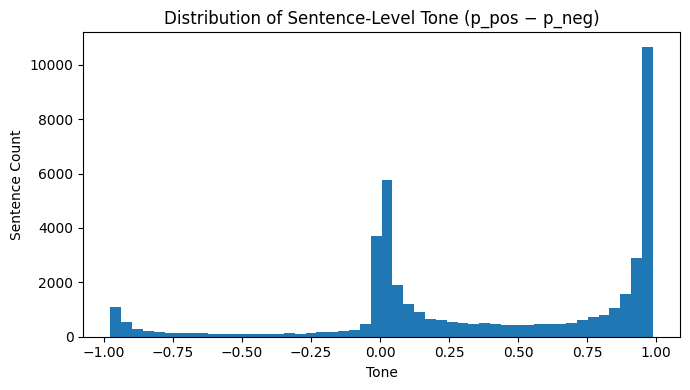

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_sent_plot = pd.read_csv(os.path.join(OUT_DIR, "sentences_scored.csv"))

plt.figure(figsize=(7,4))
plt.hist(df_sent_plot["tone"], bins=50)
plt.title("Distribution of Sentence-Level Tone (p_pos − p_neg)")
plt.xlabel("Tone")
plt.ylabel("Sentence Count")
plt.tight_layout()
plt.show()


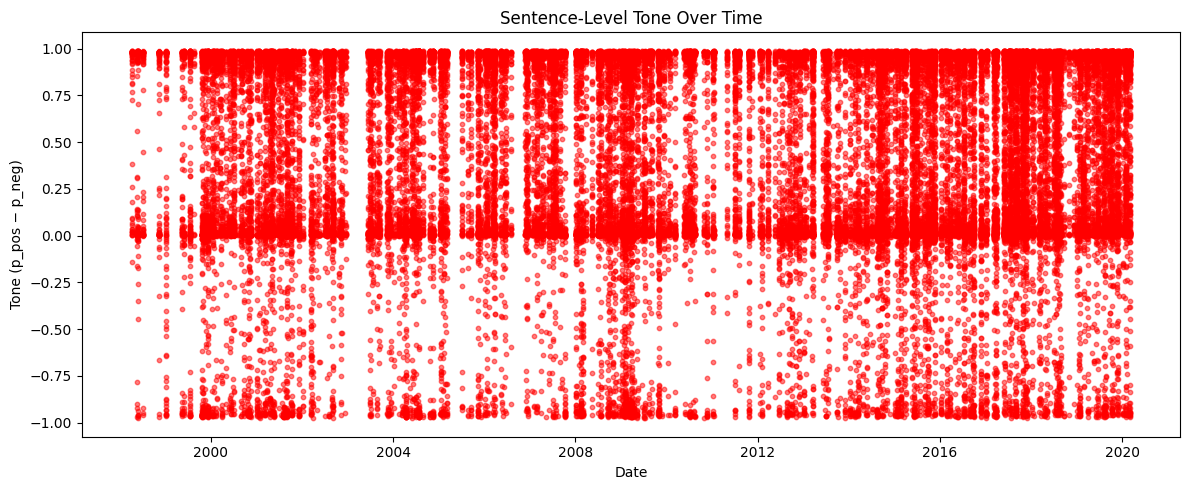

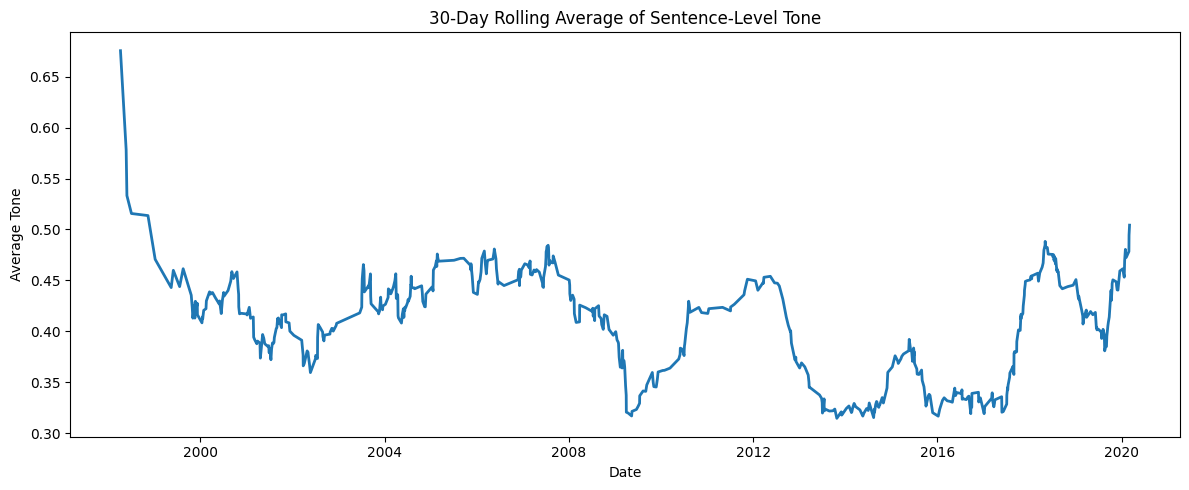

In [ ]:
df_sent_plot[DATE_COL_SPEECHES] = pd.to_datetime(df_sent_plot[DATE_COL_SPEECHES], errors="coerce")

plt.figure(figsize=(12,5))
plt.scatter(df_sent_plot[DATE_COL_SPEECHES], df_sent_plot["tone"], s=10, alpha=0.5,color="red")
plt.title("Sentence-Level Tone Over Time")
plt.xlabel("Date"); plt.ylabel("Tone (p_pos − p_neg)")
plt.tight_layout(); plt.show()

daily_mean = df_sent_plot.groupby(DATE_COL_SPEECHES)["tone"].mean().rolling(30, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_mean.index, daily_mean.values, linewidth=2)
plt.title("30-Day Rolling Average of Sentence-Level Tone")
plt.xlabel("Date"); plt.ylabel("Average Tone")
plt.tight_layout(); plt.show()

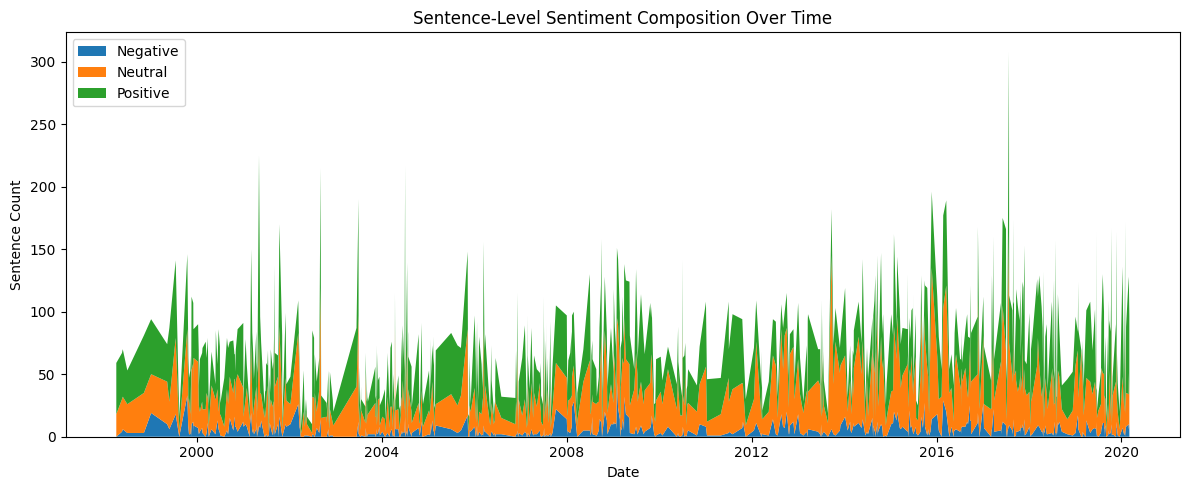

In [ ]:
label_counts = (
    df_sent_plot.groupby([DATE_COL_SPEECHES, "label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(12,5))
plt.stackplot(
    label_counts.index,
    [label_counts.get("negative", 0), label_counts.get("neutral", 0), label_counts.get("positive", 0)],
    labels=["Negative","Neutral","Positive"],
)
plt.title("Sentence-Level Sentiment Composition Over Time")
plt.xlabel("Date"); plt.ylabel("Sentence Count")
plt.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [ ]:
speech_df = pd.read_csv(f"{OUT_DIR}/speeches_aggregated.csv")
speech_df[DATE_COL_SPEECHES] = pd.to_datetime(speech_df[DATE_COL_SPEECHES], errors="coerce")
speech_df = speech_df.sort_values(DATE_COL_SPEECHES)
speech_df.head(3)

,index,Date,tone_mean,tone_median,pos_share,neg_share,neu_share,n_sent,label_majority
675,678,1998-04-07,0.675493,0.941443,0.694915,0.000000,0.305085,59,positive
674,677,1998-05-22,0.480964,0.921239,0.537313,0.059701,0.388060,67,positive
673,676,1998-05-28,0.443199,0.927701,0.542857,0.085714,0.357143,70,positive


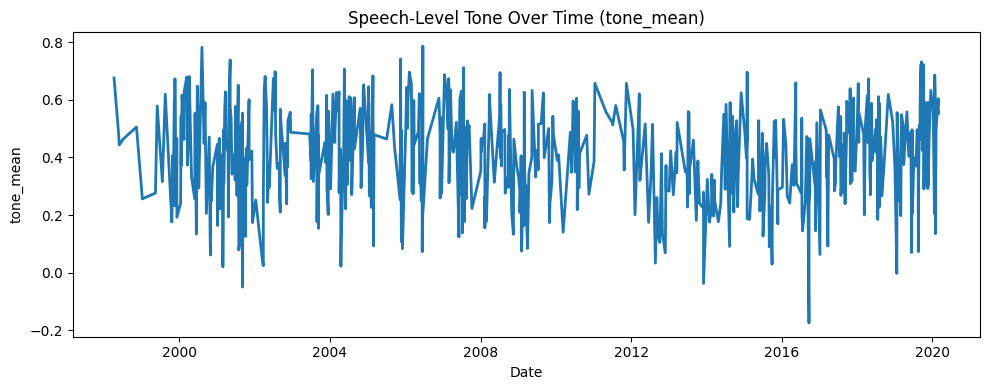

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(speech_df[DATE_COL_SPEECHES], speech_df["tone_mean"], linewidth=2)
plt.title("Speech-Level Tone Over Time (tone_mean)")
plt.xlabel("Date"); plt.ylabel("tone_mean")
plt.tight_layout(); plt.show()

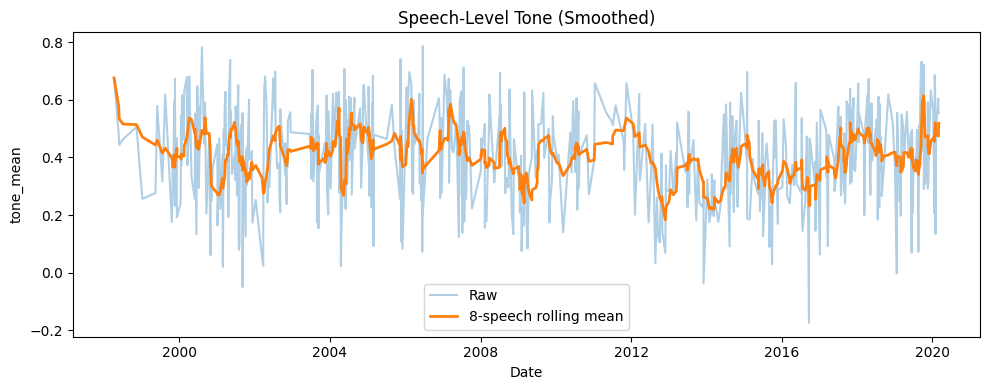

In [ ]:
speech_df["tone_mean_roll8"] = speech_df["tone_mean"].rolling(window=8, min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(speech_df[DATE_COL_SPEECHES], speech_df["tone_mean"], alpha=0.35, label="Raw")
plt.plot(speech_df[DATE_COL_SPEECHES], speech_df["tone_mean_roll8"], linewidth=2, label="8-speech rolling mean")
plt.title("Speech-Level Tone (Smoothed)")
plt.xlabel("Date"); plt.ylabel("tone_mean")
plt.legend(); plt.tight_layout(); plt.show()

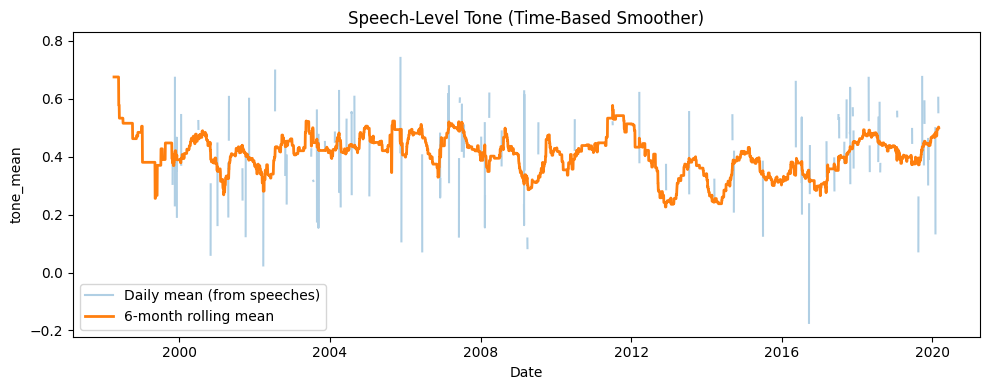

In [ ]:
daily_avg = (speech_df
             .set_index(DATE_COL_SPEECHES)["tone_mean"]
             .resample("D").mean())  # fill by day to enable time-based rolling
tone_6mo = daily_avg.rolling("180D", min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(daily_avg.index, daily_avg.values, alpha=0.35, label="Daily mean (from speeches)")
plt.plot(tone_6mo.index, tone_6mo.values, linewidth=2, label="6-month rolling mean")
plt.title("Speech-Level Tone (Time-Based Smoother)")
plt.xlabel("Date"); plt.ylabel("tone_mean")
plt.legend(); plt.tight_layout(); plt.show()

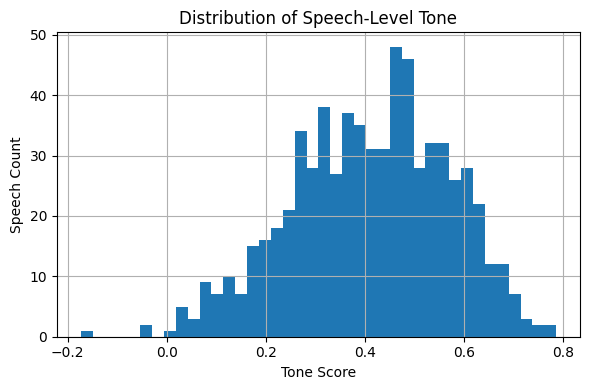

In [ ]:
plt.figure(figsize=(6,4))
speech_df["tone_mean"].hist(bins=40)
plt.title("Distribution of Speech-Level Tone")
plt.xlabel("Tone Score"); plt.ylabel("Speech Count")
plt.tight_layout(); plt.show()

/tmp/ipykernel_7120/19963980.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq="M"), "label_majority"])


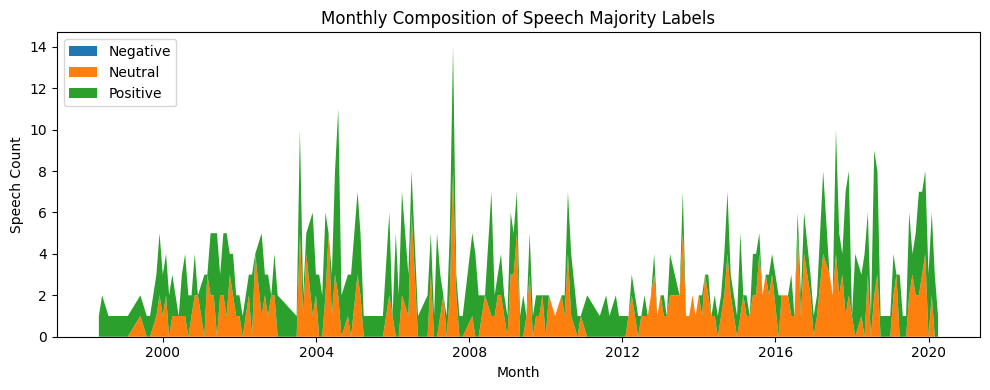

In [ ]:
# Count speeches per label per month
by_month = (speech_df
            .set_index(DATE_COL_SPEECHES)
            .groupby([pd.Grouper(freq="M"), "label_majority"])
            .size()
            .unstack(fill_value=0))

# Ensure all three columns exist
for col in ["negative","neutral","positive"]:
    if col not in by_month.columns: by_month[col] = 0

by_month = by_month[["negative","neutral","positive"]]

plt.figure(figsize=(10,4))
plt.stackplot(by_month.index,
              [by_month["negative"], by_month["neutral"], by_month["positive"]],
              labels=["Negative","Neutral","Positive"])
plt.title("Monthly Composition of Speech Majority Labels")
plt.xlabel("Month"); plt.ylabel("Speech Count")
plt.legend(loc="upper left")
plt.tight_layout(); plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 57/57 [00:04<00:00, 13.33it/s]


Validation Loss: 0.6247

Overall Metrics:
accuracy: 0.7725
precision_macro: 0.7519
recall_macro: 0.7755
f1_macro: 0.7628
precision_weighted: 0.7731
recall_weighted: 0.7725
f1_weighted: 0.7726
mcc: 0.5988

Per-Class Metrics:
      label  precision    recall  f1_score  support
0  negative   0.698630  0.784615  0.739130       65
1   neutral   0.766169  0.747573  0.756757      412
2  positive   0.790805  0.794457  0.792627      433

Classification Report:

              precision    recall  f1-score   support

    negative     0.6986    0.7846    0.7391        65
     neutral     0.7662    0.7476    0.7568       412
    positive     0.7908    0.7945    0.7926       433

    accuracy                         0.7725       910
   macro avg     0.7519    0.7755    0.7628       910
weighted avg     0.7731    0.7725    0.7726       910



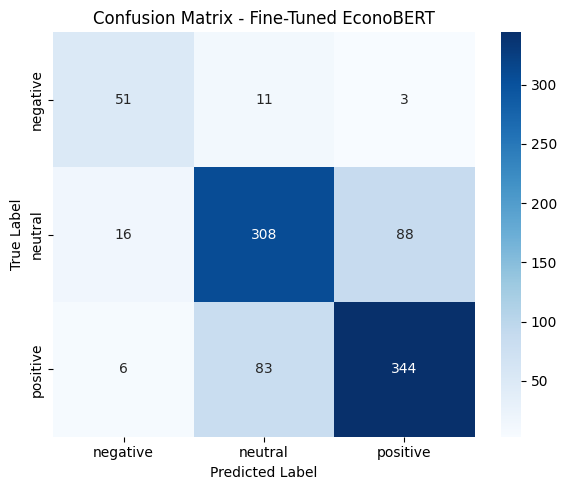

In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)
import seaborn as sns

def compute_metrics_full(preds, labels, probs=None, label_names=None):
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    acc = accuracy_score(labels, preds)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    prec_class, rec_class, f1_class, support_class = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )
    mcc = matthews_corrcoef(labels, preds)

    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "mcc": float(mcc)
    }

    per_class_df = pd.DataFrame({
        "label": label_names,
        "precision": prec_class,
        "recall": rec_class,
        "f1_score": f1_class,
        "support": support_class
    })

    return metrics, per_class_df

def evaluate_model(model, data_loader, device, loss_fn, label_order):
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)

            loss = loss_fn(out.logits, batch["labels"])
            total_loss += loss.item()

            logits = out.logits.detach().cpu().numpy()
            probs = softmax_np(logits)
            preds = probs.argmax(axis=1)
            labels = batch["labels"].detach().cpu().numpy()

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = total_loss / max(1, len(data_loader))
    metrics, per_class_df = compute_metrics_full(
        preds=all_preds,
        labels=all_labels,
        probs=np.array(all_probs),
        label_names=label_order
    )
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "val_loss": avg_loss,
        "metrics": metrics,
        "per_class_df": per_class_df,
        "confusion_matrix": cm,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "probs": np.array(all_probs)
    }

# Load best model
clf_tok = AutoTokenizer.from_pretrained(SAVE_MODEL_DIR)
clf_mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_MODEL_DIR).to(device).eval()

# Evaluate
results = evaluate_model(clf_mdl, val_dl, device, loss_fn, LABEL_ORDER)

print("Validation Loss:", round(results["val_loss"], 4))
print("\nOverall Metrics:")
for k, v in results["metrics"].items():
    print(f"{k}: {v:.4f}")

print("\nPer-Class Metrics:")
print(results["per_class_df"])

print("\nClassification Report:\n")
print(classification_report(
    results["labels"],
    results["preds"],
    target_names=LABEL_ORDER,
    digits=4,
    zero_division=0
))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    results["confusion_matrix"],
    annot=True,
    fmt="d",
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned EconoBERT")
plt.tight_layout()
plt.show()

# Save outputs
overall_metrics_df = pd.DataFrame([{
    "model": "EconoBERT",
    "val_loss": results["val_loss"],
    **results["metrics"]
}])
overall_metrics_df.to_csv(os.path.join(OUT_DIR, "econobert_overall_metrics.csv"), index=False)
results["per_class_df"].to_csv(os.path.join(OUT_DIR, "econobert_per_class_metrics.csv"), index=False)

val_eval_df = val_df[[TEXT_COL_LABELED, LABEL_COL_LABELED]].reset_index(drop=True).copy()
val_eval_df["true_label_id"] = results["labels"]
val_eval_df["pred_label_id"] = results["preds"]
val_eval_df["true_label"] = [LABEL_ORDER[i] for i in results["labels"]]
val_eval_df["pred_label"] = [LABEL_ORDER[i] for i in results["preds"]]
val_eval_df["p_neg"] = results["probs"][:, 0]
val_eval_df["p_neu"] = results["probs"][:, 1]
val_eval_df["p_pos"] = results["probs"][:, 2]
val_eval_df.to_csv(os.path.join(OUT_DIR, "econobert_val_predictions.csv"), index=False)